# Musterlösung 6

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Signal aus harmonischen Funktionen

Wie Sie in der Vorlesung gesehen haben, können periodische Signale aus Sinus- und Kosinusfunktionen aufgebaut werden. Oder allgemeiner formuliert: Die Sinus- und Kosinusfunktionen bilden eine Orthonormalbasis im Raum aller periodischer Funktionen.

Dieses Prinzip wollen wir in der ersten Aufgabe veranschaulichen, indem wir eine periodische Funktion nehmen und sie mit Sinusfunktionen annähern. Dabei werden Sie sehen, dass bereits wenige Summanden der unendlichen Reihe genügen, um die Strukturen der Ausgangsfunktion zu rekonstruieren.


##  a)


Laden Sie den Datensatz `square.txt` und plotten Sie ihn. Er beinhaltet die erste Periode eines Rechtecksignals zusammen mit der dazugehörigen Zeitachse.

### Lösung

Text(0, 0.5, 'Spannung U (V)')

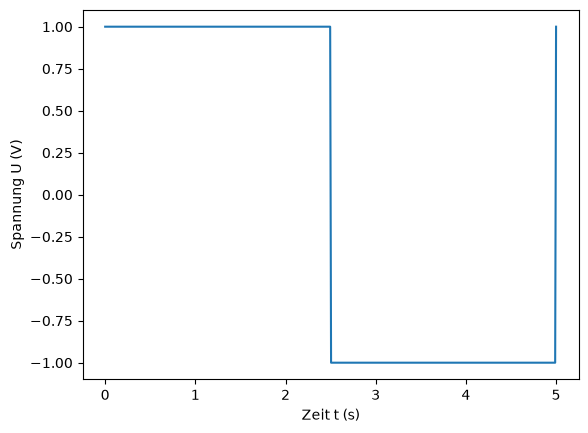

In [9]:
data = np.loadtxt('Ex06/square.txt', skiprows=1)

t = data[0, :]
square = data[1, :]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, square)
ax.set_xlabel('Zeit t (s)')
ax.set_ylabel('Spannung U (V)')


##  b)


Wir wollen nun das Signal aus einzelnen harmonischen Funktionen aufbauen. Aufgrund der Symmetrie des Signals kann man erkennen, dass es aus Sinusfunktionen aufgebaut ist (Nullstellen bei $t=0, t=T/2$ und $t=T$). Die niedrigste relevante Frequenz $f_1$ ist diejenige, die der inversen Messzeit entspricht,  und alle höheren Frequenzen müssen ein ganzzahliges Vielfaches davon sein, damit sie die Periodizitätsbedingung $U(t + T) = U(t)$ erfüllen.

Wir wollen das Signal also als
    
$$ U(t) = \sum_{n=0}^{N} a_n \sin(2\pi f_n t) $$
    
ausdrücken, wobei $f_n = n \cdot f_1$ ist und $N$ die Anzahl Frequenzkomponenten, die berücksichtigt werden. Die richtigen Amplituden $a_n$, um auf diese Weise ein beliebiges Signal zu konstruieren, können mithilfe der Fouriertransformation berechnet werden, wie Sie in Aufgabe 2 sehen werden. In diesem Fall sind sie gegeben als

$$ a_n = \frac{4}{\pi n} \textrm{ für ungerade } n,\\ a_n = 0 \textrm{ für gerade }n.$$

Schreiben Sie eine Funktion, die die Summe in Gleichung (1) berechnet, wobei als Argumente die Zeitachse $t$ und die Anzahl $N$ der berücksichtigten Frequenzen übergeben werden. Plotten Sie dann das so konstruierte Signal zusammen mit der Rechteckfunktion für verschiedene $N$, um sich zu veranschaulichen, wie das Rechtecksignal immer besser angenähert wird, wenn Sie mehr Frequenzkomponenten dazuaddieren.

### Lösung

In [ ]:
# Wir benutzen die bereits gegebene Zeitachse, um damit die Sinusfunktionen zu definieren
def sum_sin(t, n):
    # Grundfrequenz aufgrund der Länge der Zeitachse
    f1 = 1 / t[-1]
    
    # Initialisieren des Arrays für die Summierung
    signal = np.zeros(len(t))
    
    # Summe über alle Amplituden
    # Die Schleife geht bis n+1, damit die Frequenz f_n auch mit dabei ist.
    # Wir nehmen direkt nur ungerade j, da die Amplituden für gerade j Null ist.
    for j in range(1, n+1,2):
        a_j = 4 / (np.pi * j)  # Amplitude wie angegeben
        signal += a_j * np.sin(2*np.pi * f1 * j * t)
    return signal

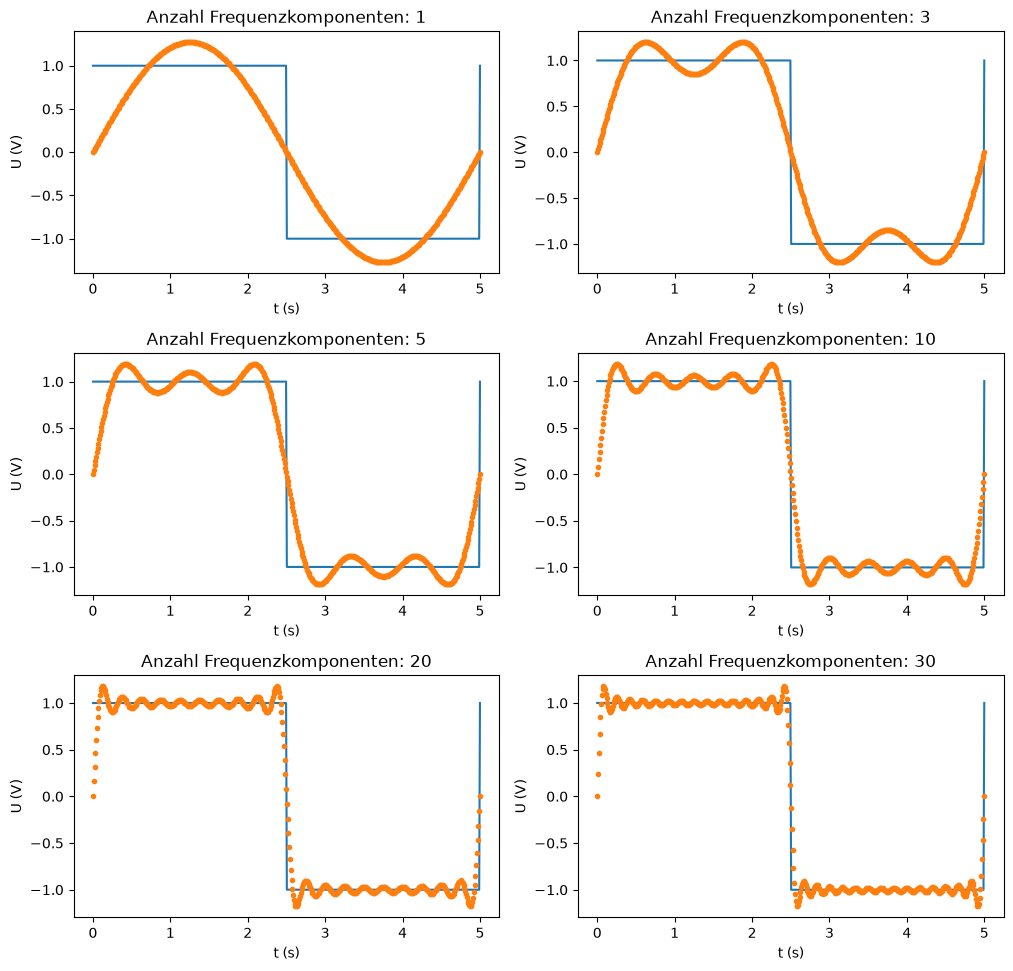

In [9]:
cm = 1 / 2.54
fig = plt.figure(figsize=(26*cm, 32*cm))

# Die Anzahl der Komponenten, über die summiert werden soll
n_freq = [1, 3, 5, 10, 20, 30]

for i, n in enumerate(n_freq):
    # Neuer Plot mit der Rechtecksfunktion zum Vergleich
    ax = fig.add_subplot(4, 2, i+1)
    ax.plot(t, square)
    
    # Berechne das Signal mit n Frequenzen
    signal = sum_sin(t, n)
    
    # Plotten der aufsummierten Sinusfunktionen.
    ax.plot(t, signal,'.')
    ax.set_xlabel('t (s)')
    ax.set_ylabel('U (V)')
    ax.set_title('Anzahl Frequenzkomponenten: {:n}'.format(n))
    
plt.tight_layout()

Man sieht deutlich, wie die ersten paar Summanden einen grossen Einfluss auf das resultierende Signal haben, während es nicht mehr so darauf ankommt, ob man 20 oder 30 Frequenzen nimmt. Dass die höheren Frequenzen einen kleineren Einfluss haben kann man auch daran sehen, dass die Amplitude mit $1/n$ bzw $1/f_n$ abnimmt.

#  Aufgabe 2 Fouriertransformation

Im obigen Beispiel haben wir als Basis Sinusfunktionen genommen, da sie genau die richtige Phase für unser Signal hatten. Im Allgemeinen ist dies jedoch nicht der Fall, und man muss entweder für jede Frequenz eine Phase $\phi_n$ einführen,

$$x(t) = \sum_{n=0}^{\infty} a_n \sin(2\pi f_n t + \phi_n),$$

einen Kosinusterm hinzufügen,

$$x(t) = \sum_{n=0}^{\infty} a_n \sin(2\pi f_n t) + b_n \cos(2\pi f_n t),$$

oder, was in den meisten Fällen gemacht wird, man benutzt die Exponentialfunktion als Basis,

$$x(t) = \sum_{n=-\infty}^{\infty} a_n e^{i2\pi f_n t},$$
    
womit wir bei der Definition aus der Vorlesung angelangt sind.

In dieser Aufgabe geht es darum, die Amplituden $a_n$ für ein beliebiges Signal zu ermitteln, also die Fouriertransformation auf ein Signal anzuwenden. In Numpy existiert dazu ein ganzes Modul mit entsprechenden Funktionen, von denen wir hier aber lediglich `np.fft.fft` und `np.fft.fftfreq` anschauen werden. Auf der Website https://numpy.org/doc/stable/reference/routines.fft.html finden Sie die Definition der diskreten Fouriertransformation, die in von Numpy verwendet wird. 

In der Vorlesung wurde die diskrete Fouriertrasformation definiert als

$$a_n = \frac{1}{N}\sum_{k=0}^{N-1} x(t_k)e^{-i2\pi f_n t_k},$$

wobei wir die diskretisierte Zeitachse $t_k = k\cdot\Delta t$ betrachten. Durch Einsetzen von

$$
f_n = n \cdot f_1 = \frac{n}{N \cdot \Delta t},\\
t_k = k \cdot \Delta t
$$

erhält man die Form

$$a_n = \frac{1}{N}\sum_{k=0}^{N-1} x(t_k)e^{-i2\pi n k / N},$$

die Sie auch in der Dokumentation von Numpy finden. Beachten Sie, dass der Normierungsfaktor $\frac{1}{N}$ bei Numpy in der Rücktransformation vorhanden ist, was aber lediglich eine Frage der Konvention ist.

## a)

Laden Sie die Daten aus `'Signal.txt'` und plotten Sie sie. Welche Frequenzen können Sie von Auge erkennen (zoomen Sie in der x-Achse entsprechend)?

###  Lösung

(1.2, 1.35)

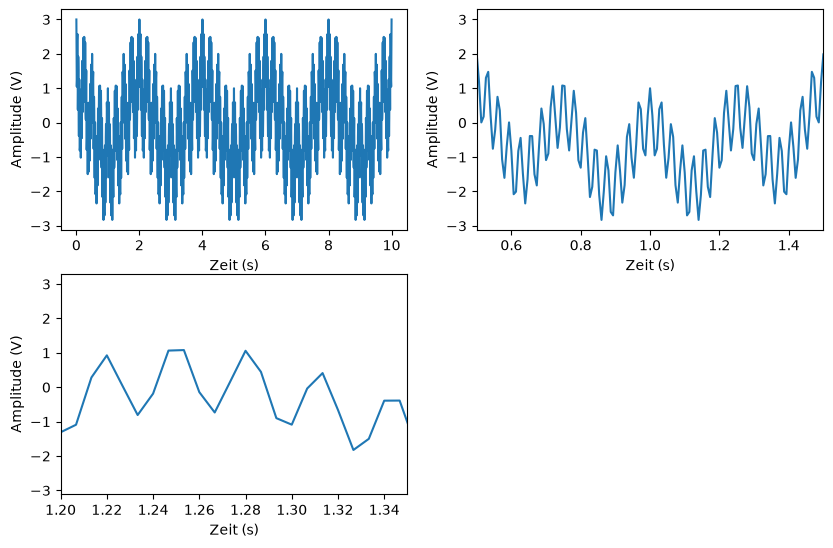

In [11]:
data = np.loadtxt('Ex06/Signal.txt', skiprows=1)
t = data[0, :]
V = data[1, :]

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 16*cm))
ax = fig.add_subplot(2, 2, 1)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')

ax = fig.add_subplot(2, 2, 2)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')
ax.set_xlim(0.5, 1.5)

ax = fig.add_subplot(2, 2, 3)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')
ax.set_xlim(1.2, 1.35)

Im ersten Plot sehen wir eine Oszillation von etwa 2 s / 0.5 Hz, im zweiten von etwa 0.25 s / 4 Hz und im letzten  sieht man Peaks im Abstand von ca. 0.03 s / 33 Hz.

##  b)

Bestimmen Sie aufgrund der Zeitachse die Nyquist-Frequenz, sowie die Frequenzuflösung, die Sie für die Fouriertransformation erwarten.

###  Lösung

In [12]:
f_ny = 1 / (2 * (t[1] - t[0]))
df = 1 / t[-1]

print('Die Nyquist-Frequenz ist: {:0.2f} Hz\nund die Frequenzauflösung beträgt: {:0.2f} Hz'.format(f_ny,df))

Die Nyquist-Frequenz ist: 75.00 Hz
und die Frequenzauflösung beträgt: 0.10 Hz


## c)

Berechnen Sie nun die Fouriertransformation der Daten. Unter `Implementation details` des obigen Links finden Sie, in welcher Reihenfolge die Amplituden von `np.fft.fft` zurückgegeben werden. Die Funktion `np.fft.fftfreq` gibt Ihnen die entsprechend geordnete Frequenzachse. Plotten Sie zuerst die Frequenzen $f_n$ selbst als Funktion des Index $n$ um zu veranschaulichen, wie die Daten geordnet sind, und dann die spektrale Leistungsdichte als Funktion der Frequenzen. Finden Sie die Frequenzen wieder, die Sie in a) gefunden haben?

### Lösung

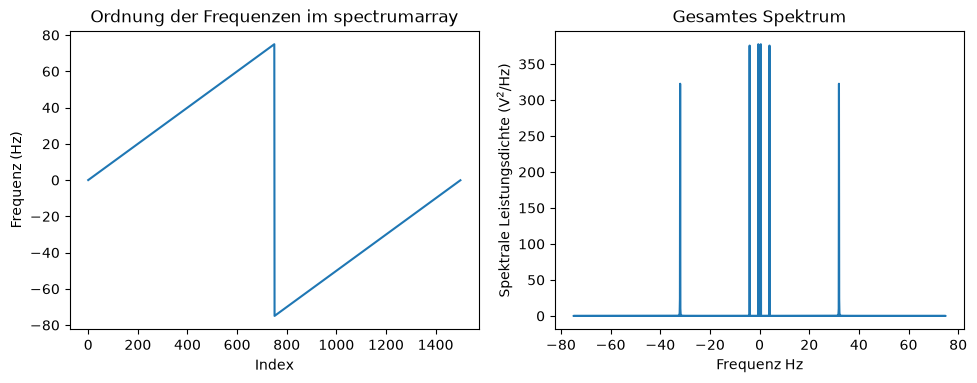

In [ ]:
N = len(t)
dt = t[1] - t[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(V)
# Berechnen der spektralen Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(f)
ax.set_xlabel('Index')
ax.set_ylabel('Frequenz (Hz)')
ax.set_title('Ordnung der Frequenzen im spectrumarray')

ax = fig.add_subplot(1, 2, 2)
ax.plot(f, psd)
ax.set_xlabel('Frequenz Hz')
ax.set_ylabel(r'Spektrale Leistungsdichte (V$^2$/Hz)')
ax.set_title('Gesamtes Spektrum')

fig.tight_layout()

Das Array beginnt bei 0, dann kommen zuerst die positiven Frequenzen bis $f_{\mathrm{Ny}}$. Danach kommen aufsteigend die negativen Frequenzen beginnend bei $-f_{\mathrm{Ny}}$.

Da wir ein reelles Signal anschauen, genügt es die positiven Frequenzen zu betrachten, denn es gilt dass $a_n=a_m^*$ wenn $f_n=-f_m$. Dies wird anschaulich, wenn man die Summe aus einer positiven und einer negativen Frequenz betrachtet:

$$ a_n e^{2\pi i f_n t} + a_m e^{2\pi i f_m t}=a_n e^{2\pi i f_n t} + a_n^* e^{-2\pi i f_n t} = 2|a_n|\cos(2\pi f_n t+\phi) \in \mathbb{R}.$$

Wenn man also nur auf die positiven Frequenzachse schaut und entsprechend die Achsen etwas vergrössert, sieht man die drei Frequenzen:

[750 751 749 752 748 753 747 754 746 755]


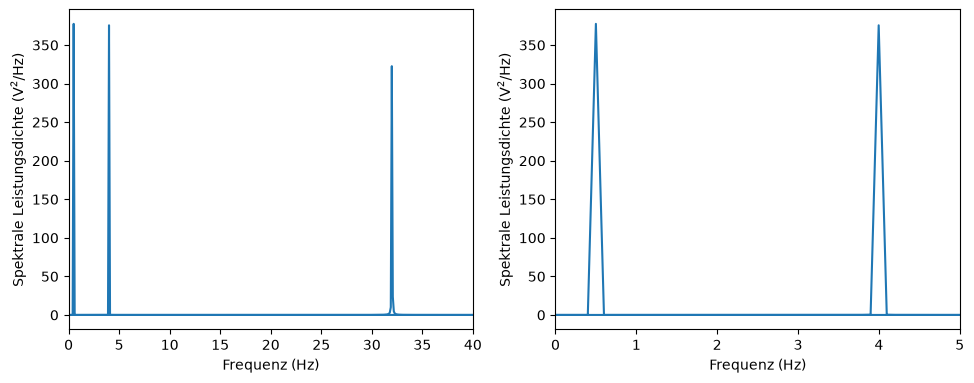

In [ ]:
cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(f, psd)
ax.set_xlim(0, 40)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(f, psd)
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')


fig.tight_layout()

Wenn wir nun nur die positiven Frequenzen plotten, sehen wir Peaks bei 0.5 Hz, 4 Hz und 32 Hz, was den Erwartungen von a) entspricht. Wir können auch überprüfen, dass die kleinste Frequenz grösser ist als die Auflösung.

###  d)

Betrachten Sie nochmals das Recktecksignal aus Aufgabe 1. Berechnen Sie die Fouriertransformation und plotten Sie die spektrale Leistungsdichte. Sie sollten das Verhalten der Amplituden aus Aufgabe 1 rekonstruieren können, sprich die Abnahme mit $1/n$ sowie, dass die Frequenzen mit geraden $n$ verschwindend klein sind. Da aber die Normierungskonvention der `numpy` Fouriertransformation sowie die Basis anders sind, wird die Grösse der Amplituden anders sein.

###  Lösung:

Text(0, 0.5, 'Spektrale Leistungsdichte (V$^2$/Hz)')

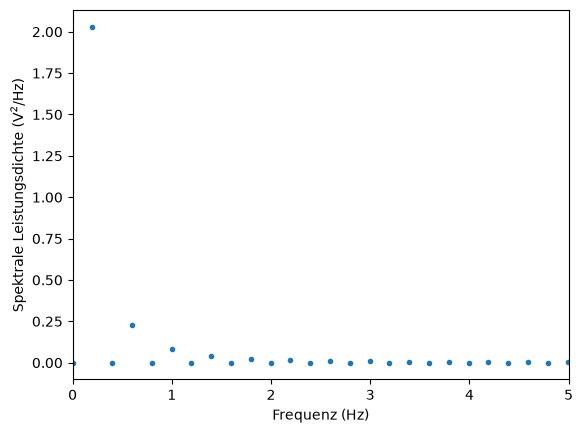

In [21]:
# Laden der Daten
data = np.loadtxt('Ex06/square.txt', skiprows=1)
t = data[0, :]
square = data[1, :]

N = len(t)
dt = t[1] - t[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(square)
# Berechnen der spektralen Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

# Plotten
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, psd,'.')
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')

Um das Spektrum mit den Amplituden aus Aufgabe 1 zu vergleichen, müssen wir das Spektrum wegen der unterschiedlichen Konventionen anders normieren.

Text(0, 0.5, 'Amplitude (V)')

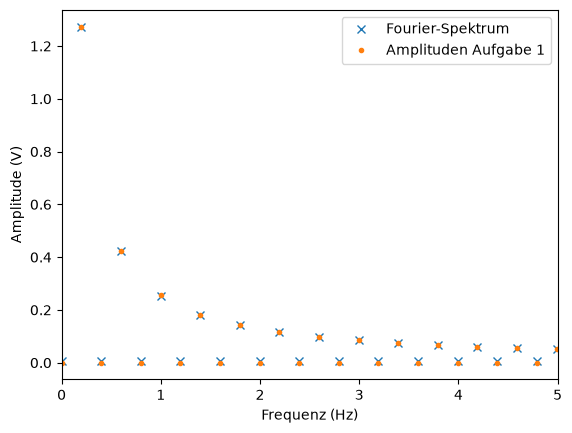

In [ ]:
# Amplituden wie in Aufgabe 1 angegeben:
N = len(f)
amplitudes = np.zeros(int(N/2))
for i in range(1, len(amplitudes), 2):
    amplitudes[i] = 4 / (np.pi * i)
    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, abs(spectrum) * 2 / len(spectrum), 'x', label='Fourier-Spektrum')
ax.plot(f[:int(N/2)], amplitudes, '.', label='Amplituden Aufgabe 1')
ax.legend()
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Amplitude (V)')